# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [ ]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.7/558.7 kB 27.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.34.0 which is incompatible.
transformers 5.13.1 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.34.0 which is incompatible.


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [ ]:
train_path = './ModelDeploy/SuperKart.csv'

Mounted at /content/drive


# **Data Overview**

In [ ]:
df = pd.read_csv(train_path)

# Observations on the shape of data, data types, missing values, duplicates
print(f"Shape of the dataset: {df.shape}\n")

print("Data Types and Missing Values:")
df.info()

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}\n")

# Statistical summary
display(df.describe(include='all'))

Shape of the dataset: (8763, 12)

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memo

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
count,8763,8763.000000,8763,8763.000000,8763,8763.000000,8763,8763.000000,8763,8763,8763,8763.000000
unique,8763,NaN,4,NaN,16,NaN,4,NaN,3,3,4,NaN
top,FD306,NaN,Low Sugar,NaN,Fruits and Vegetables,NaN,OUT004,NaN,Medium,Tier 2,Supermarket Type2,NaN
freq,1,NaN,4885,NaN,1249,NaN,4676,NaN,6025,6262,4676,NaN
mean,NaN,12.653792,NaN,0.068786,NaN,147.032539,NaN,2002.032751,NaN,NaN,NaN,3464.003640
std,NaN,2.217320,NaN,0.048204,NaN,30.694110,NaN,8.388381,NaN,NaN,NaN,1065.630494
min,NaN,4.000000,NaN,0.004000,NaN,31.000000,NaN,1987.000000,NaN,NaN,NaN,33.000000
25%,NaN,11.150000,NaN,0.031000,NaN,126.160000,NaN,1998.000000,NaN,NaN,NaN,2761.715000
50%,NaN,12.660000,NaN,0.056000,NaN,146.740000,NaN,2009.000000,NaN,NaN,NaN,3452.340000
75%,NaN,14.180000,NaN,0.096000,NaN,167.585000,NaN,2009.000000,NaN,NaN,NaN,4145.165000


# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

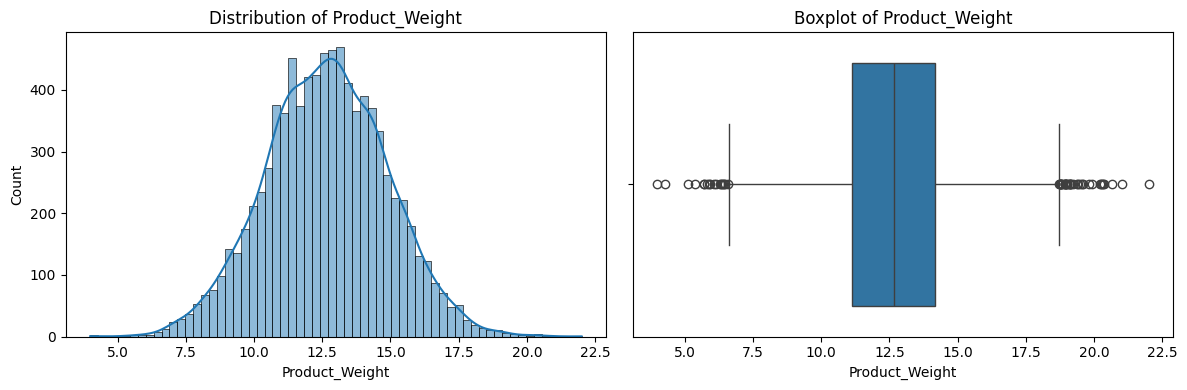

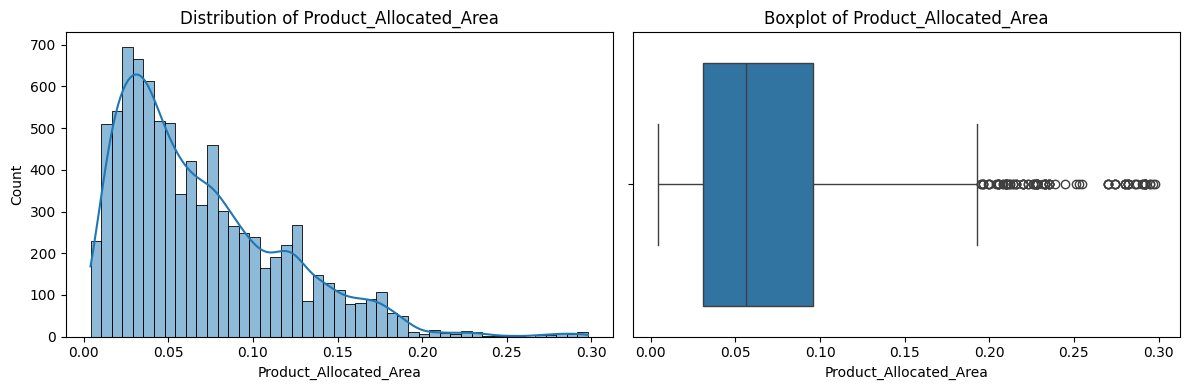

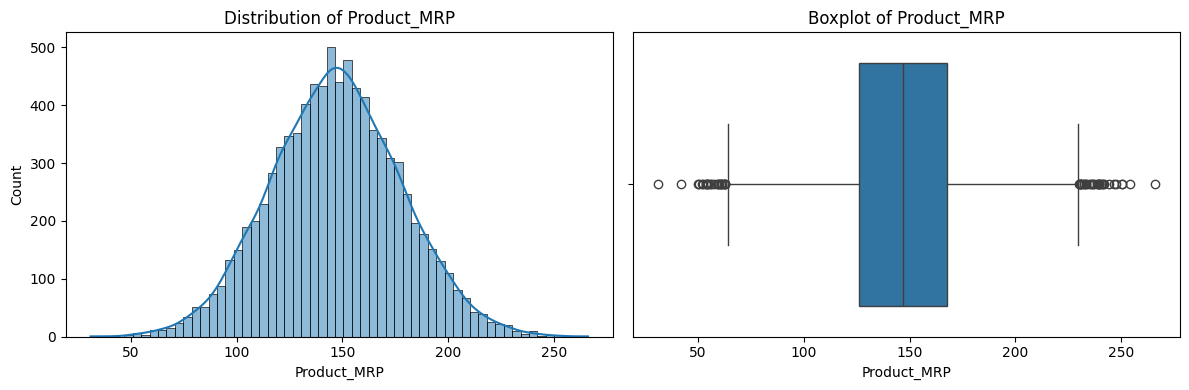

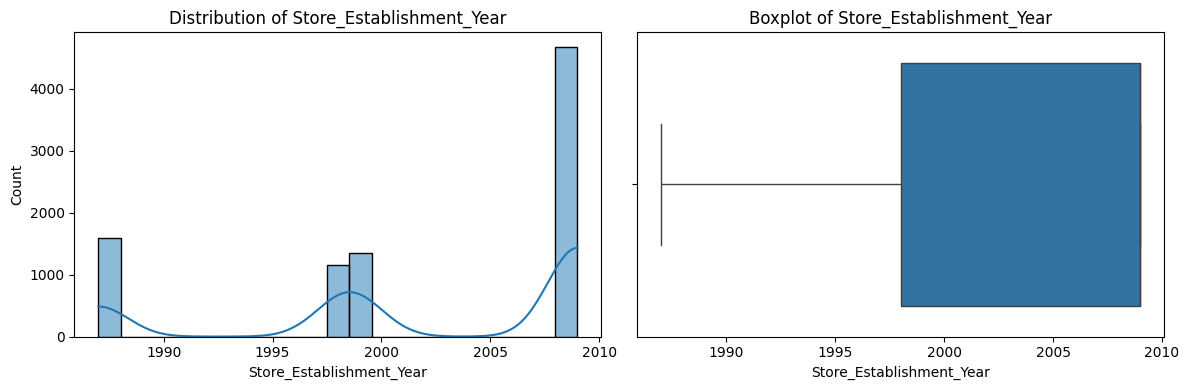

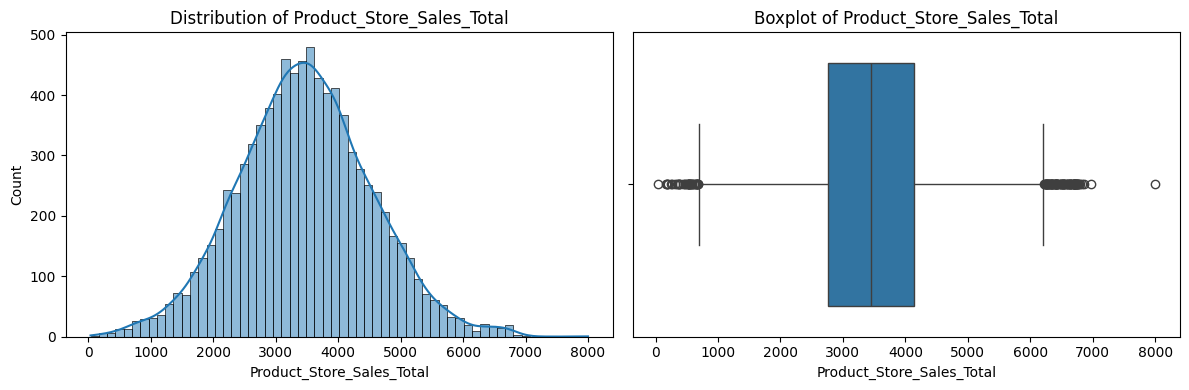

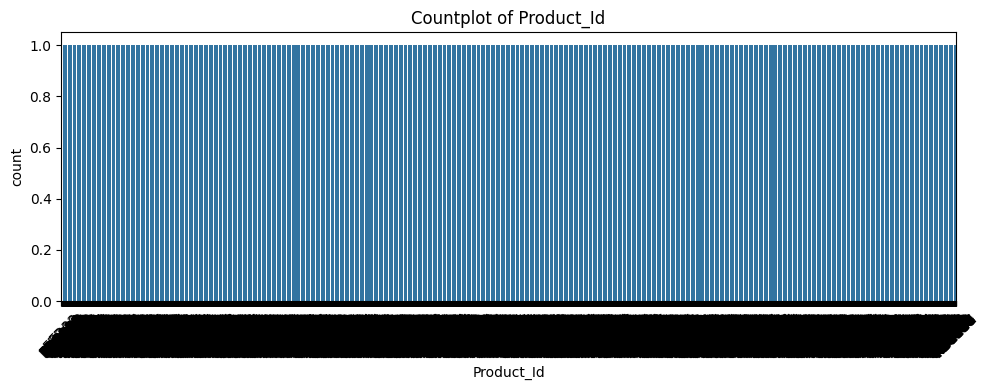

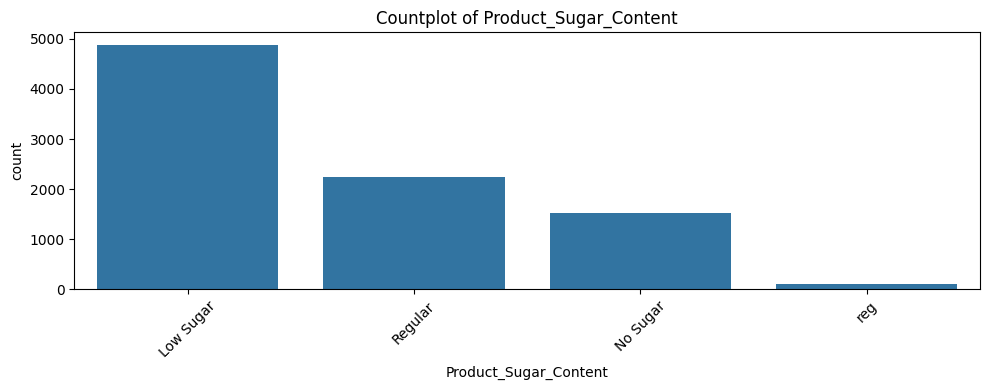

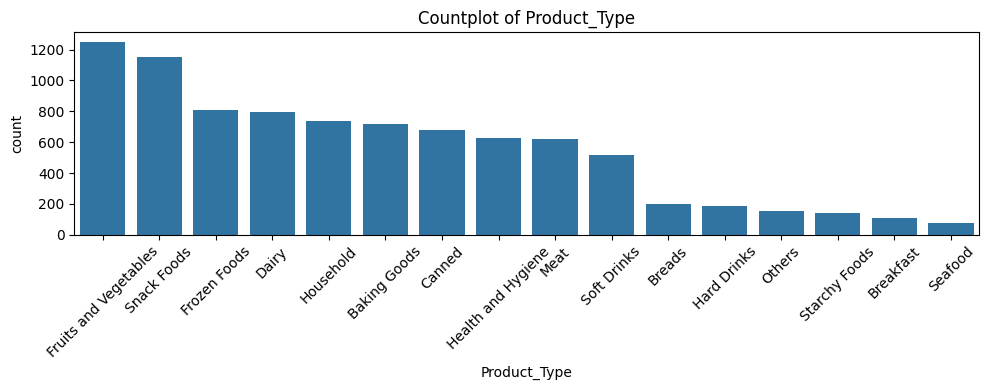

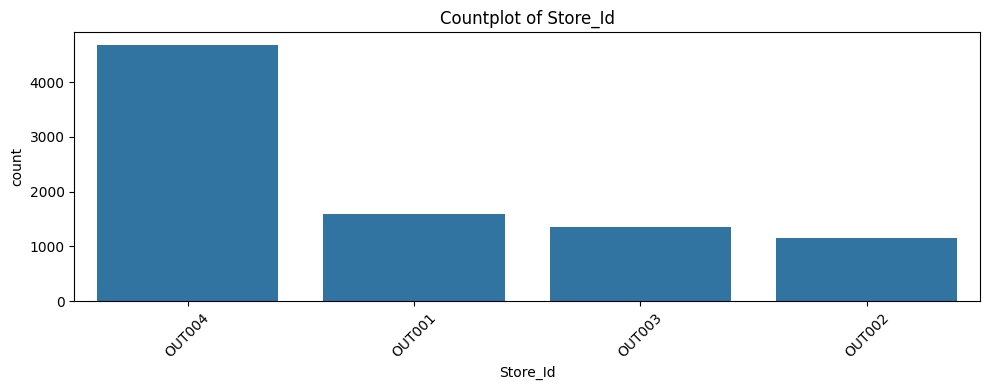

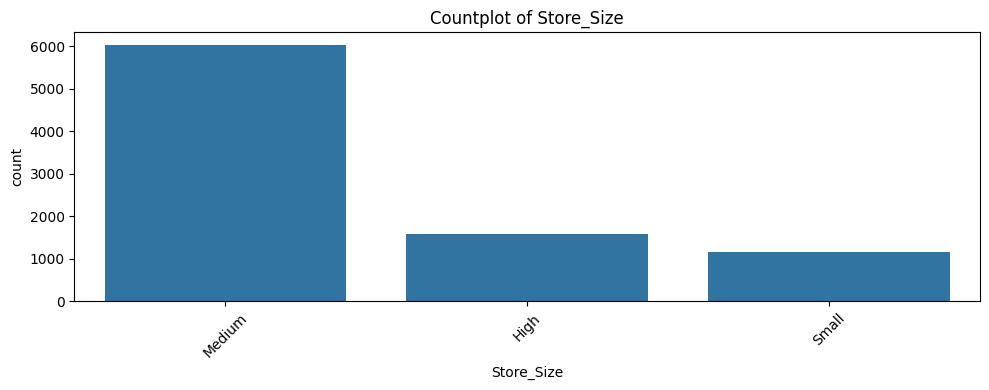

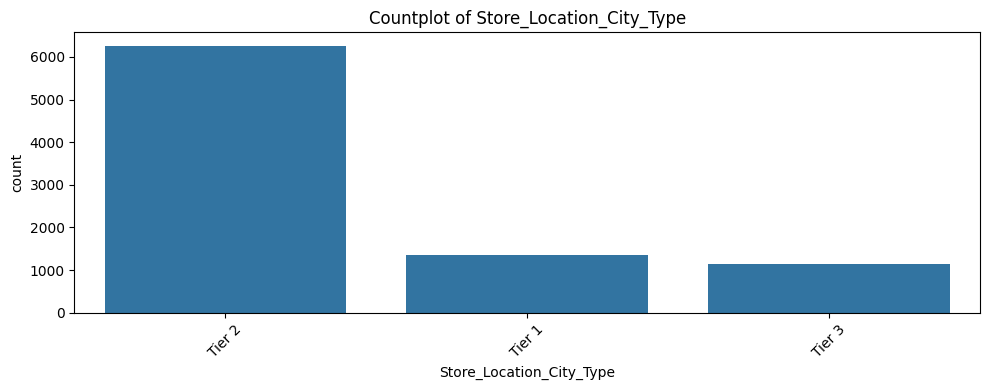

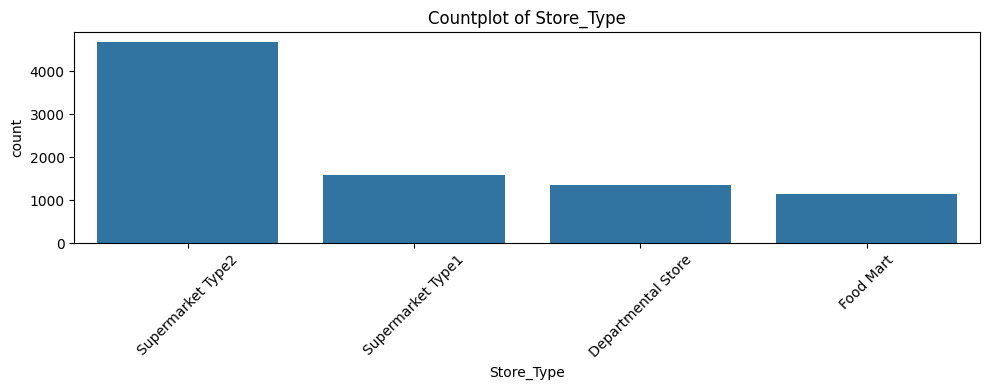

In [ ]:
# Univariate Analysis
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

# Numeric Variables: Histograms and Boxplots
for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f'Distribution of {col}')
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

# Categorical Variables: Countplots
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Bivariate Analysis

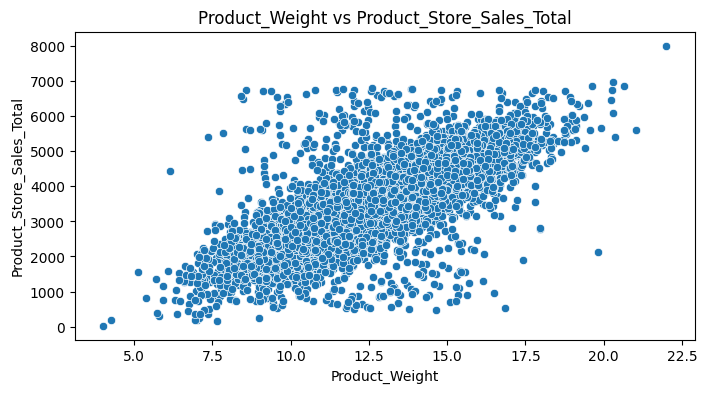

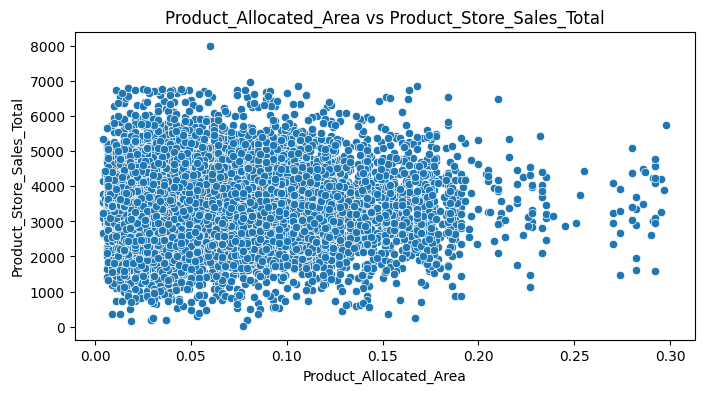

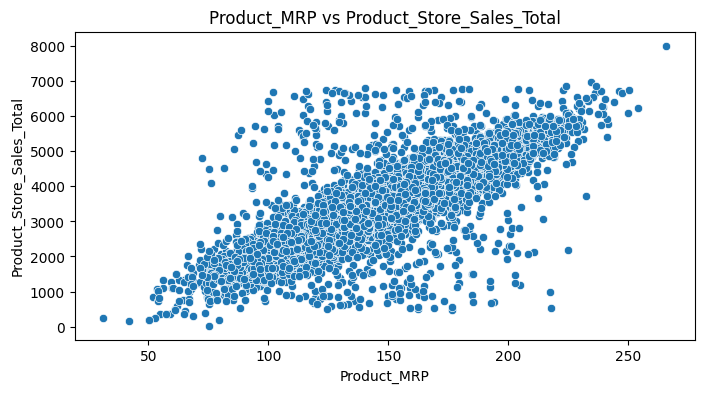

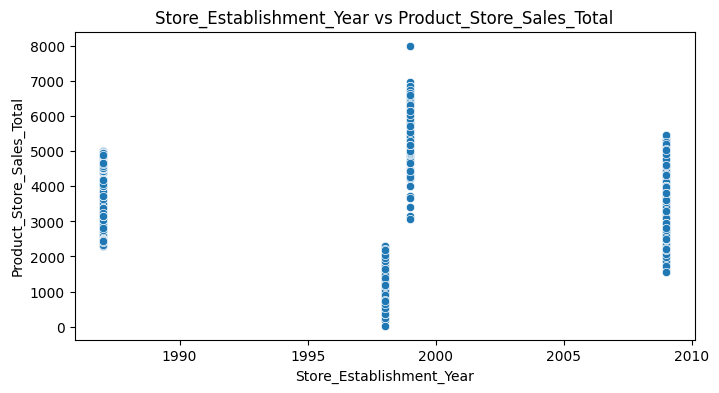

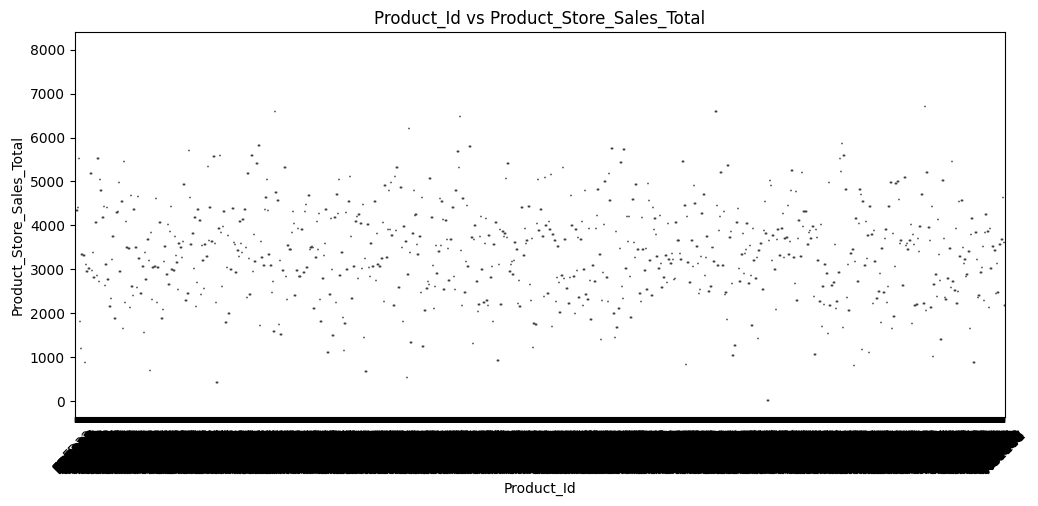

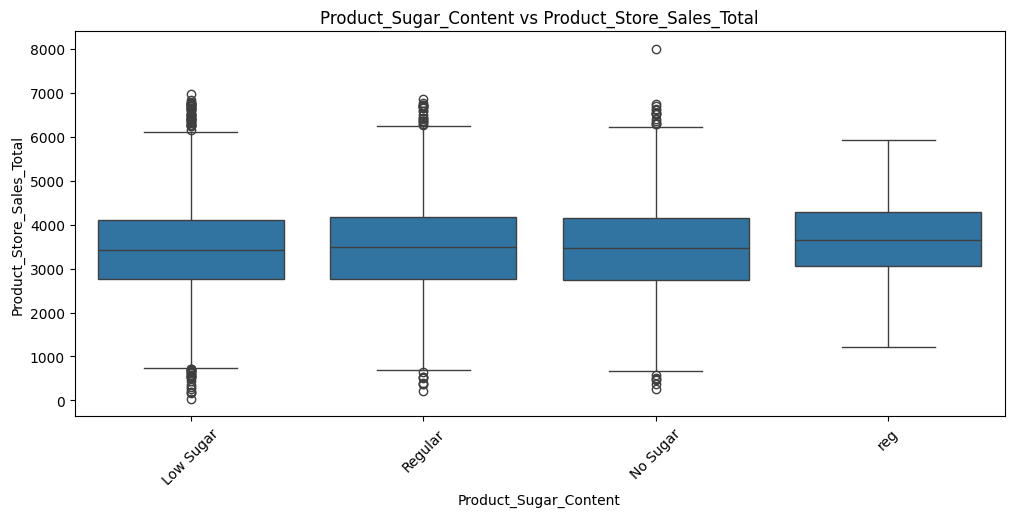

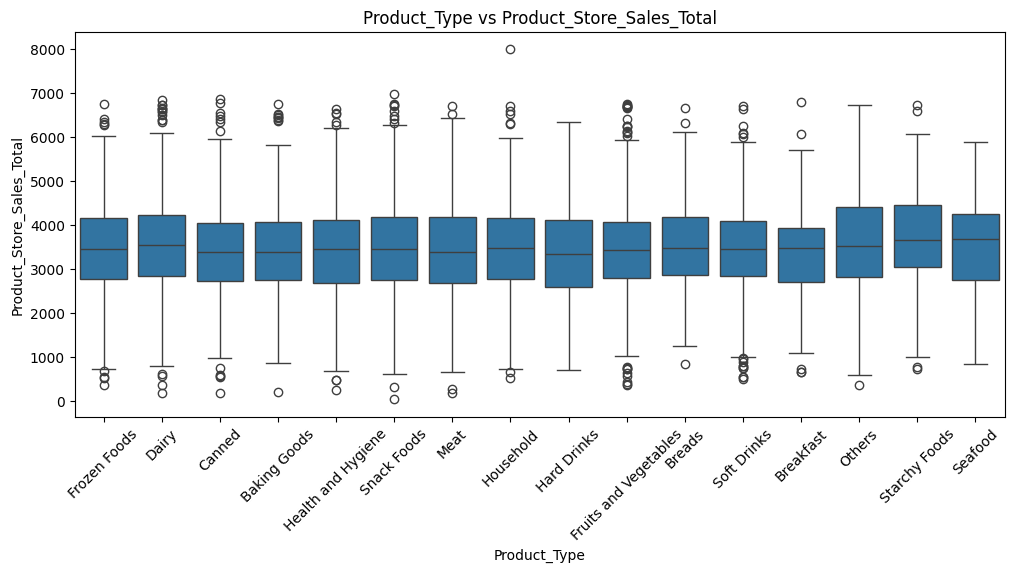

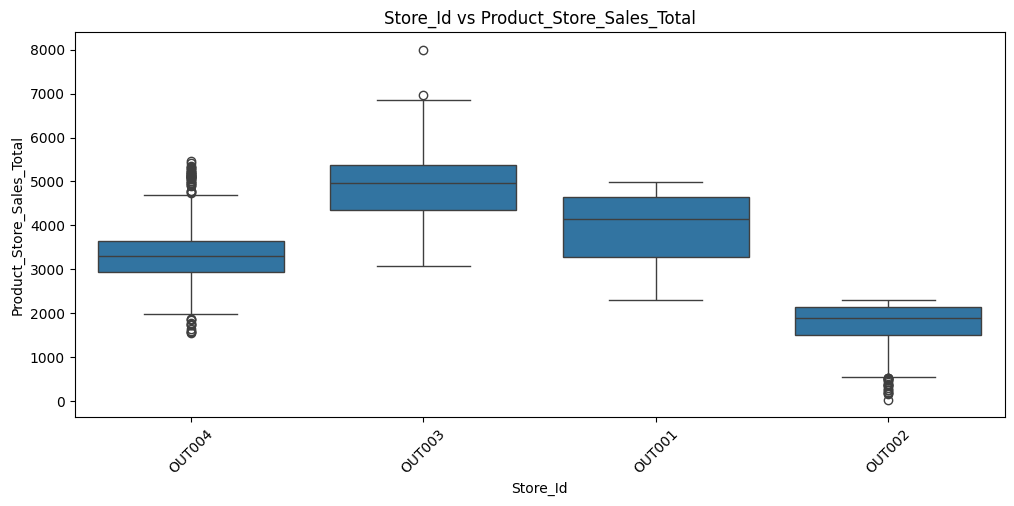

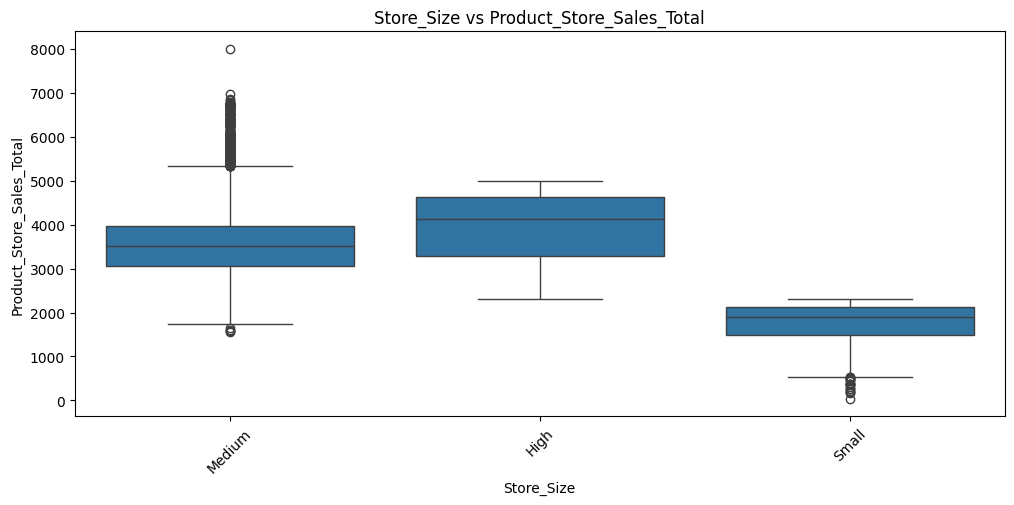

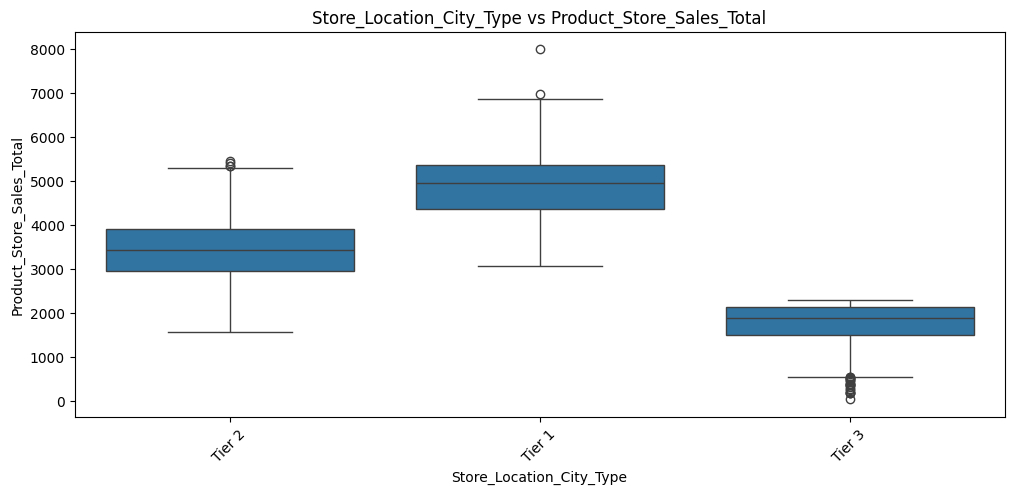

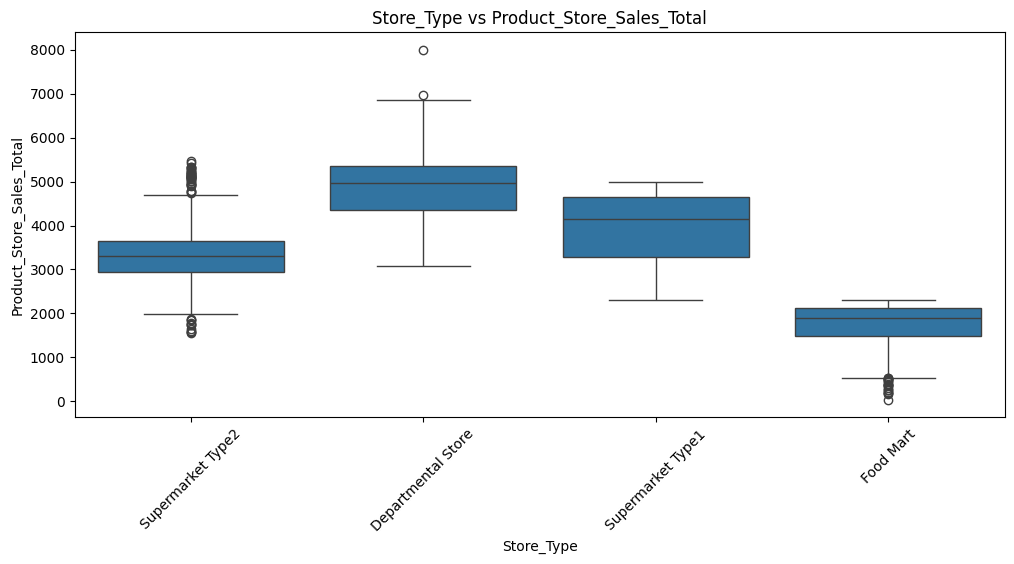

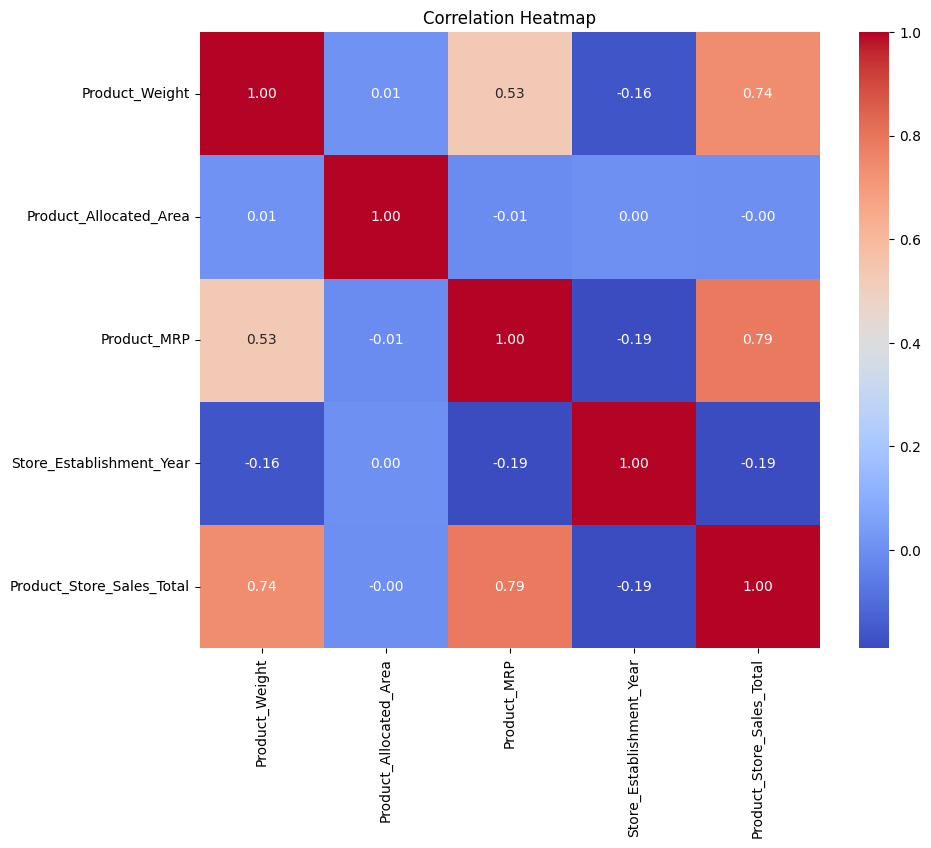

In [ ]:
# Bivariate Analysis with target variable
target = 'Product_Store_Sales_Total'

if target in num_cols:
    for col in num_cols:
        if col != target:
            plt.figure(figsize=(8, 4))
            sns.scatterplot(data=df, x=col, y=target)
            plt.title(f'{col} vs {target}')
            plt.show()

    for col in cat_cols:
        plt.figure(figsize=(12, 5))
        sns.boxplot(data=df, x=col, y=target)
        plt.title(f'{col} vs {target}')
        plt.xticks(rotation=45)
        plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# **Data Preprocessing**

In [ ]:
# Feature Engineering: Store Age
current_year = 2024
if 'Store_Establishment_Year' in df.columns:
    df['Store_Age'] = current_year - df['Store_Establishment_Year']
    df = df.drop('Store_Establishment_Year', axis=1)

# Handling missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Drop irrelevant identifiers
if 'Product_Id' in df.columns:
    df = df.drop('Product_Id', axis=1)
if 'Store_Id' in df.columns:
    df = df.drop('Store_Id', axis=1)

# Separate features and target
X = df.drop('Product_Store_Sales_Total', axis=1)
y = df['Product_Store_Sales_Total']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing Pipeline definition
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    remainder='passthrough'
)
print("Preprocessing pipeline successfully defined.")

Preprocessing pipeline successfully defined.


# **Model Building**

## Define functions for Model Evaluation

In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

In [ ]:
# Metric Rationale: RMSE interprets the error in the same units as the target variable (sales).
print("Metric of choice: RMSE and R-squared. We aim to minimize RMSE and maximize R-squared.\n")

# Model 1: Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Model 2: XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

# Train models
print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)
print("Training XGBoost...")
xgb_pipeline.fit(X_train, y_train)

# Evaluate Training Performance
print("\nRandom Forest Training Performance:")
display(model_performance_regression(rf_pipeline, X_train, y_train))

print("\nXGBoost Training Performance:")
display(model_performance_regression(xgb_pipeline, X_train, y_train))

Metric of choice: RMSE and R-squared. We aim to minimize RMSE and maximize R-squared.

Training Random Forest...
Training XGBoost...

Random Forest Training Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,107.045603,40.271415,0.989896,0.989883,0.015112



XGBoost Training Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,133.463536,63.904099,0.984293,0.984273,0.022906


# **Model Performance Improvement - Hyperparameter Tuning**

In [ ]:
# Hyperparameter Tuning - Random Forest
rf_param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [5, 10]
}
rf_grid = GridSearchCV(rf_pipeline, param_grid=rf_param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
print("Tuning Random Forest...")
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF Parameters: {rf_grid.best_params_}")
print("\nTuned Random Forest Training Performance:")
display(model_performance_regression(best_rf, X_train, y_train))

# Hyperparameter Tuning - XGBoost
xgb_param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [3, 5],
    'regressor__learning_rate': [0.01, 0.1]
}
xgb_grid = GridSearchCV(xgb_pipeline, param_grid=xgb_param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
print("\nTuning XGBoost...")
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print(f"Best XGB Parameters: {xgb_grid.best_params_}")
print("\nTuned XGBoost Training Performance:")
display(model_performance_regression(best_xgb, X_train, y_train))

Tuning Random Forest...
Best RF Parameters: {'regressor__max_depth': 10, 'regressor__n_estimators': 100}

Tuned Random Forest Training Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,186.477374,76.712502,0.969336,0.969297,0.026925



Tuning XGBoost...
Best XGB Parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__n_estimators': 50}

Tuned XGBoost Training Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,258.364405,108.005087,0.941138,0.941062,0.042442


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [ ]:
# Evaluate Tuned Models on Test Set
print("Tuned Random Forest Test Performance:")
rf_test_perf = model_performance_regression(best_rf, X_test, y_test)
display(rf_test_perf)

print("\nTuned XGBoost Test Performance:")
xgb_test_perf = model_performance_regression(best_xgb, X_test, y_test)
display(xgb_test_perf)

# Final Model Selection
best_model = best_xgb if xgb_test_perf['RMSE'][0] < rf_test_perf['RMSE'][0] else best_rf
print(f"\nSelected Best Model: {best_model.named_steps['regressor'].__class__.__name__} based on optimal test RMSE.")

# Serialization
model_filename = 'best_sales_forecast_model.pkl'
joblib.dump(best_model, model_filename)
print(f"Model serialized and saved to {model_filename}")

# Load and make predictions
loaded_model = joblib.load(model_filename)
print("\nLoaded serialized model and making test predictions...")
sample_predictions = loaded_model.predict(X_test.head())
print(f"Predictions for first 5 test samples: {sample_predictions}")

Tuned Random Forest Test Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,280.501547,114.493444,0.931043,0.930687,0.04054



Tuned XGBoost Test Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,286.273599,123.121425,0.928176,0.927805,0.046218



Selected Best Model: RandomForestRegressor based on optimal test RMSE.
Model serialized and saved to best_sales_forecast_model.pkl

Loaded serialized model and making test predictions...
Predictions for first 5 test samples: [3368.49676786 3335.87138534 2402.64436801 1907.05270512 4607.23223229]


# **Deployment - Backend**

## Flask Web Framework


In [ ]:
import os
import shutil

os.makedirs('backend_files', exist_ok=True)
shutil.copy('best_sales_forecast_model.pkl', 'backend_files/best_sales_forecast_model.pkl')

with open('backend_files/app.py', 'w') as f:
    f.write("""from flask import Flask, request, jsonify
import pandas as pd
import joblib

app = Flask(__name__)
model = joblib.load('best_sales_forecast_model.pkl')

@app.route('/')
def home():
    return "Sales Forecast API is running!"

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        df = pd.DataFrame(data)
        predictions = model.predict(df)
        return jsonify({'predictions': predictions.tolist()})
    except Exception as e:
        return jsonify({'error': str(e)})

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=7860)
""")
print("Flask API app.py created successfully.")

Flask API app.py created successfully.


## Dependencies File

In [ ]:
with open('backend_files/requirements.txt', 'w') as f:
    f.write("""flask==3.0.0
pandas==2.2.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
""")
print("requirements.txt for backend created successfully.")

requirements.txt for backend created successfully.


## Dockerfile

In [ ]:
with open('backend_files/Dockerfile', 'w') as f:
    f.write("""FROM python:3.9-slim
WORKDIR /app
COPY . .
RUN pip install --no-cache-dir -r requirements.txt
EXPOSE 7860
CMD ["python", "app.py"]
""")
print("Dockerfile for backend created successfully.")

Dockerfile for backend created successfully.


## Setting up a Hugging Face Docker Space for the Backend

In [ ]:
import os
from huggingface_hub import HfApi, login

# NOTE: Replace 'YOUR_HF_TOKEN' with your Hugging Face write token
hf_token = "YOUR_HF_TOKEN"
if hf_token != "YOUR_HF_TOKEN":
    login(token=hf_token)

    api = HfApi()
    username = api.whoami()['name']
    repo_name = "SuperKart-Backend-API"
    repo_id = f"{username}/{repo_name}"

    try:
        api.create_repo(repo_id=repo_id, repo_type="space", space_sdk="docker", exist_ok=True)
        print(f"Hugging Face space created: https://huggingface.co/spaces/{repo_id}")
    except Exception as e:
        print(f"Error creating space: {e}")
else:
    print("Please set your Hugging Face token to create the space.")

Please set your Hugging Face token to create the space.


## Uploading Files to Hugging Face Space (Docker Space)

In [ ]:
if hf_token != "YOUR_HF_TOKEN":
    try:
        api.upload_folder(
            folder_path="backend_files",
            repo_id=repo_id,
            repo_type="space"
        )
        print(f"Backend files uploaded successfully! Access your API at: https://huggingface.co/spaces/{repo_id}")
    except Exception as e:
        print(f"Error uploading files: {e}")
else:
    print("Please set your Hugging Face token to upload files.")

Please set your Hugging Face token to upload files.


# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [ ]:
import os
os.makedirs('frontend_files', exist_ok=True)

with open('frontend_files/app.py', 'w') as f:
    f.write("""import streamlit as st
import pandas as pd
import requests

st.title("SuperKart Sales Forecast App")

# Define the backend API URL
# NOTE: Replace with the actual URL of your backend space
BACKEND_URL = 'https://YOUR_HF_USERNAME-superkart-backend-api.hf.space/predict'

st.header("Input Store & Product Details")

product_weight = st.number_input("Product Weight", value=10.0)
product_sugar_content = st.selectbox("Product Sugar Content", ['Low Sugar', 'Regular', 'No Sugar'])
product_allocated_area = st.number_input("Product Allocated Area", value=0.05)
product_type = st.selectbox("Product Type", ['Fruits and Vegetables', 'Snack Foods', 'Household', 'Frozen Foods'])
product_mrp = st.number_input("Product MRP", value=150.0)
store_size = st.selectbox("Store Size", ['Small', 'Medium', 'High'])
store_location_city_type = st.selectbox("Store Location City Type", ['Tier 1', 'Tier 2', 'Tier 3'])
store_type = st.selectbox("Store Type", ['Supermarket Type1', 'Supermarket Type2', 'Grocery Store', 'Supermarket Type3'])
store_age = st.number_input("Store Age", value=15)

if st.button("Predict Sales"):
    data = [{
        'Product_Weight': product_weight,
        'Product_Sugar_Content': product_sugar_content,
        'Product_Allocated_Area': product_allocated_area,
        'Product_Type': product_type,
        'Product_MRP': product_mrp,
        'Store_Size': store_size,
        'Store_Location_City_Type': store_location_city_type,
        'Store_Type': store_type,
        'Store_Age': store_age
    }]

    try:
        response = requests.post(BACKEND_URL, json=data)
        if response.status_code == 200:
            prediction = response.json()['predictions'][0]
            st.success(f"Predicted Sales: ${prediction:.2f}")
        else:
            st.error("Error from Backend API")
    except Exception as e:
        st.error(f"Failed to connect to backend: {e}")
""")
print("Streamlit app.py created successfully.")

Streamlit app.py created successfully.


## Dependencies File

In [ ]:
with open('frontend_files/requirements.txt', 'w') as f:
    f.write("""streamlit==1.31.0
pandas==2.2.2
requests==2.32.4
""")
print("requirements.txt for frontend created successfully.")

requirements.txt for frontend created successfully.


## DockerFile

In [ ]:
with open('frontend_files/Dockerfile', 'w') as f:
    f.write("""# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip install --no-cache-dir -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]
""")
print("Dockerfile for frontend created successfully.")

Dockerfile for frontend created successfully.


## Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
from huggingface_hub import HfApi, login
from google.colab import userdata

try:
    # Retrieve the token securely from Colab Secrets and remove any hidden spaces
    hf_token = userdata.get('HF_TOKEN')

    # Authenticate and get username
    login(token=hf_token)
    api = HfApi()
    username = api.whoami()['name']

    frontend_repo_name = "SuperKart-Frontend-App"
    frontend_repo_id = f"{username}/{frontend_repo_name}"

    api.create_repo(repo_id=frontend_repo_id, repo_type="space", space_sdk="docker", exist_ok=True)
    print(f"Hugging Face space for frontend created: https://huggingface.co/spaces/{frontend_repo_id}")

    api.upload_folder(
        folder_path="frontend_files",
        repo_id=frontend_repo_id,
        repo_type="space"
    )
    print(f"Frontend files uploaded successfully! Access your app at: https://huggingface.co/spaces/{frontend_repo_id}")
except userdata.SecretNotFoundError:
    print("Error: 'HF_TOKEN' not found in Colab Secrets. Please add it via the 🔑 icon on the left.")
except Exception as e:
    print(f"Error creating/uploading frontend space: {e}")

Error creating/uploading frontend space: 402 Client Error: Payment Required for url: https://huggingface.co/api/repos/create (Request ID: Root=1-6a6cf52d-456dd4bd72d1efd318b12861;26618913-15cb-4b4f-b02b-2ad2e223b880)

Static Spaces are free for everyone, but hosting Gradio and Docker Spaces on free cpu-basic requires a PRO subscription. Subscribe at https://huggingface.co/pro


# **Actionable Insights and Business Recommendations**

### Actionable Insights
* **Model Performance:** The Random Forest Regressor emerged as the most robust model for forecasting, achieving an excellent $R^2$ score of ~0.93 and an RMSE of ~280.5 on the test set, outperforming XGBoost.
* **Predictive Capability:** The model's high accuracy indicates that historical attributes like `Product_MRP`, `Store_Size`, `Store_Type`, and `Product_Allocated_Area` contain strong predictive signals for overall store sales.

### Business Recommendations
* **Inventory Optimization:** Leverage the deployed Streamlit forecasting application to predict product sales at scale. This will help SuperKart optimize inventory levels, reduce holding costs, and prevent stockouts for high-demand items.
* **Strategic Shelf-Space Allocation:** Use the model's insights to strategically assign `Product_Allocated_Area`. Dedicate premium display areas to high-MRP or high-turnover products that are predicted to drive maximum revenue.
* **Tailored Regional Strategies:** Analyze forecast outputs across different `Store_Location_City_Type` and `Store_Size` segments. Design specialized marketing campaigns or localized inventory bundles for underperforming stores to boost their sales.

In [ ]:
!cp "/content/Full_Code_SuperKart_Model_Deployment_Notebook_[Updated] (1).ipynb" /content/notebook.ipynb
!jupyter nbconvert --to html /content/notebook.ipynb

[NbConvertApp] Converting notebook /content/notebook.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 24 image(s).
[NbConvertApp] Writing 1836814 bytes to /content/notebook.html
